#### Import the Libraries

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
print("All good 🚀")

All good 🚀


#### Load the Dataset

In [60]:
statistical_df = pd.read_csv("../data/processed/bed_occupancy_timeseries.csv")

In [61]:
statistical_df["date"] = pd.to_datetime(statistical_df["date"])

##### Check Available Hospitals and Wards

In [62]:
statistical_df[["hospital_id", "ward"]].drop_duplicates().sort_values(
    ["hospital_id", "ward"]
)

,hospital_id,ward
0,HHN-BIR-01,Cardiology Ward
731,HHN-BIR-01,Day Case Unit
1462,HHN-BIR-01,General Medicine Ward A
2193,HHN-BIR-01,General Medicine Ward B
2924,HHN-BIR-01,Icu
3655,HHN-BIR-01,Oncology Ward
4386,HHN-BIR-01,Orthopaedics Ward A
5117,HHN-BIR-01,Orthopaedics Ward B
5848,HHN-EDI-01,Cardiology Ward
6579,HHN-EDI-01,Day Case Unit


#### Select One Representative Ward from Each Major Type

In [63]:
representative_series = [

    ("HHN-LON-01", "Orthopaedics Ward A"),
    ("HHN-LON-02", "Icu"),
    ("HHN-BIR-01", "Cardiology Ward"),
    ("HHN-MAN-01", "General Medicine Ward A"),
    ("HHN-EDI-01", "Day Case Unit")

]

##### Create a Function for One Time Series 

In [64]:
def get_time_series(df, hospital, ward):

    ts = df[
        (df["hospital_id"] == hospital) &
        (df["ward"] == ward)
    ].copy()

    ts = ts.sort_values("date")

    ts.set_index("date", inplace=True)

    return ts

##### Check Each Series

In [65]:
for hospital, ward in representative_series:

    ts = get_time_series(statistical_df, hospital, ward)

    print("="*60)
    print(f"Hospital : {hospital}")
    print(f"Ward     : {ward}")
    print(f"Records  : {len(ts)}")
    print(f"Start    : {ts.index.min()}")
    print(f"End      : {ts.index.max()}")

Hospital : HHN-LON-01
Ward     : Orthopaedics Ward A
Records  : 731
Start    : 2024-01-01 00:00:00
End      : 2025-12-31 00:00:00
Hospital : HHN-LON-02
Ward     : Icu
Records  : 731
Start    : 2024-01-01 00:00:00
End      : 2025-12-31 00:00:00
Hospital : HHN-BIR-01
Ward     : Cardiology Ward
Records  : 731
Start    : 2024-01-01 00:00:00
End      : 2025-12-31 00:00:00
Hospital : HHN-MAN-01
Ward     : General Medicine Ward A
Records  : 731
Start    : 2024-01-01 00:00:00
End      : 2025-12-31 00:00:00
Hospital : HHN-EDI-01
Ward     : Day Case Unit
Records  : 731
Start    : 2024-01-01 00:00:00
End      : 2025-12-31 00:00:00


##### Plot the Bed Occupancy Trend

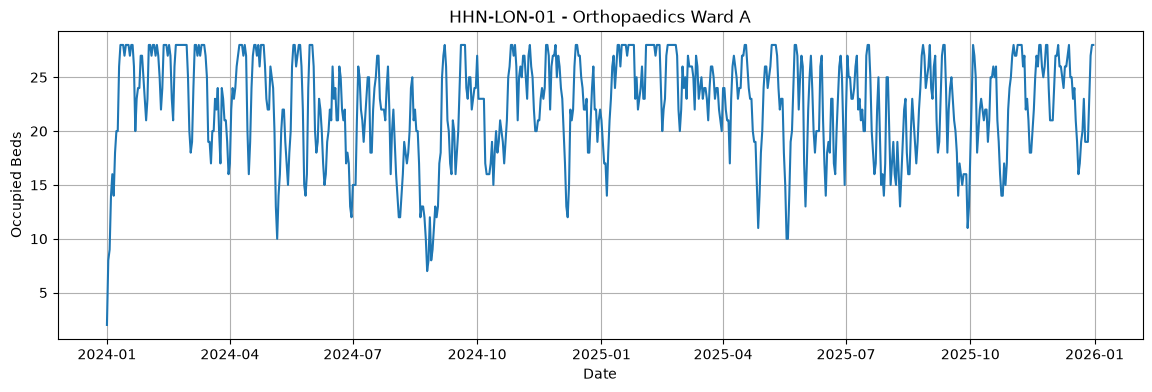

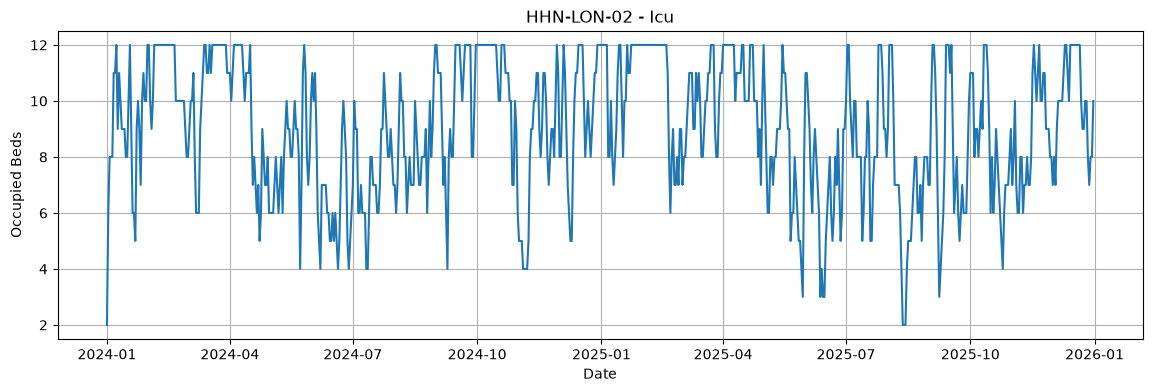

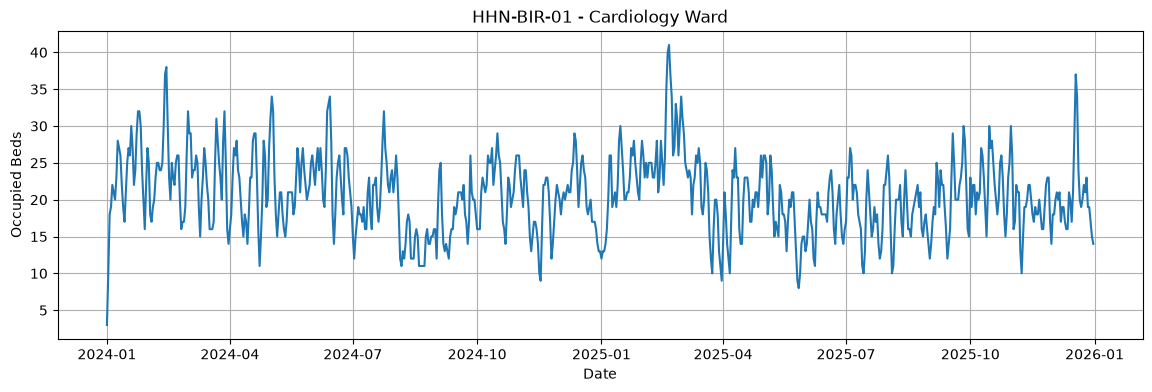

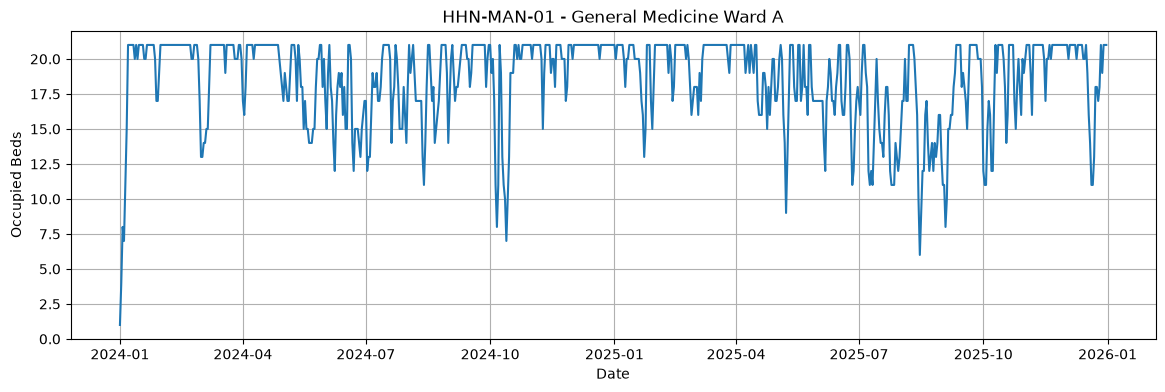

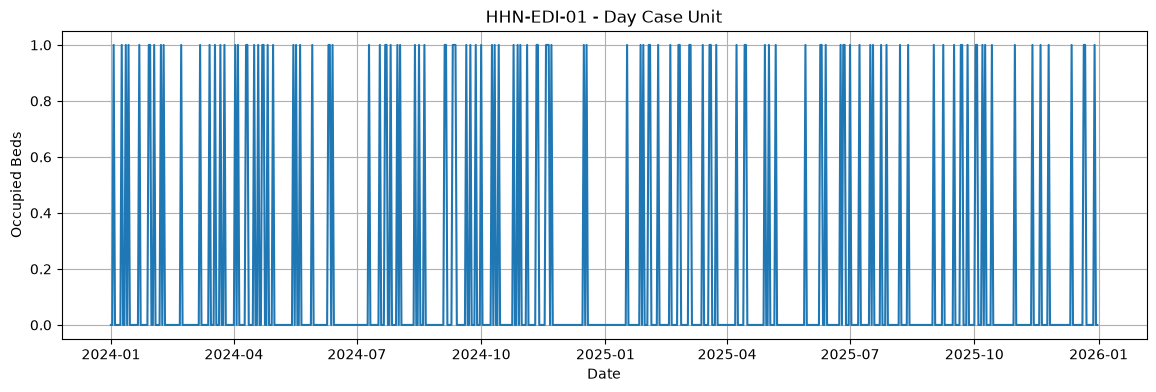

In [66]:
for hospital, ward in representative_series:

    ts = get_time_series(statistical_df, hospital, ward)

    plt.figure(figsize=(14,4))

    plt.plot(
        ts.index,
        ts["occupied_beds"]
    )
    plt.title(f"{hospital} - {ward}")
    plt.xlabel("Date")
    plt.ylabel("Occupied Beds")
    plt.grid(True)
    plt.show()

HHN-LON-01 – Orthopaedics Ward A
Bed occupancy remained consistently high throughout the period, usually between 20 and 28 occupied beds.
There were occasional short drops, but occupancy quickly returned to high levels, indicating sustained demand.

HHN-LON-02 – ICU
ICU occupancy fluctuated throughout the period, generally ranging between 5 and 12 occupied beds.
Despite frequent ups and downs, occupancy often reached or stayed close to full capacity (12 beds).

HHN-BIR-01 – Cardiology Ward
Cardiology showed the greatest variability, with occupancy mostly between 15 and 25 beds, but with several sharp peaks above 30 beds. This suggests periods of unusually high demand interspersed with more moderate occupancy levels.

Overall insight:
All three wards exhibit fluctuations in bed occupancy over time, but Orthopaedics maintained the most consistently high occupancy, ICU experienced regular short-term fluctuations while often operating near capacity, and Cardiology showed the largest swings, indicating more variable patient demand

#### Stationarity Test - For forecasting, we use Augmented Dickey Fuller(ADF)

In [67]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(ts["occupied_beds"])

print("ADF Statistic:", result[0])

print("p-value:", result[1])

ADF Statistic: -8.983846110197796
p-value: 7.18917586249592e-15


The Augmented Dickey-Fuller (ADF) test was conducted to assess the stationarity of the occupied_beds time series. The test produced an ADF statistic of -8.98 and a p-value of 7.19 × 10⁻¹⁵, which is well below the 0.05 significance level. Therefore, the null hypothesis was rejected, and the alternative hypothesis is accepted, indicating that the occupied_beds time series is stationary.

Since the bed occupancy time series is stationary, meaning its statistical properties (such as mean and variance) remain relatively stable over time. Therefore, differencing is not required before modelling.

#### Autocorrelation - measures how today's bed occupancy relates to previous days and weeks.
##### Plot the ACF.

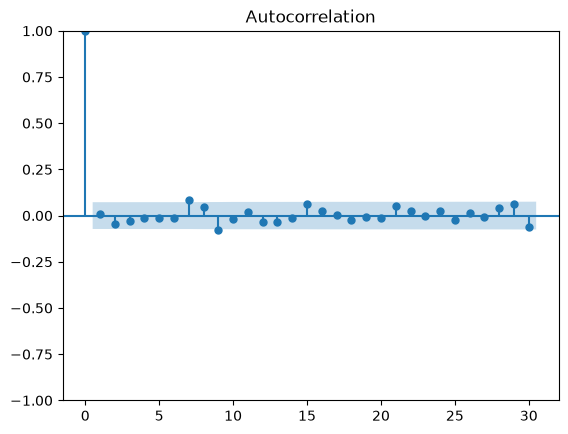

In [68]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(
    ts["occupied_beds"],
    lags=30
)

plt.show()

The autocorrelation plot shows that most lag values lie within the 95% confidence interval, indicating weak autocorrelation in the occupancy series. However, there are small positive spikes around lag 7 and lag 28, suggesting a possible weekly recurring pattern in bed occupancy.


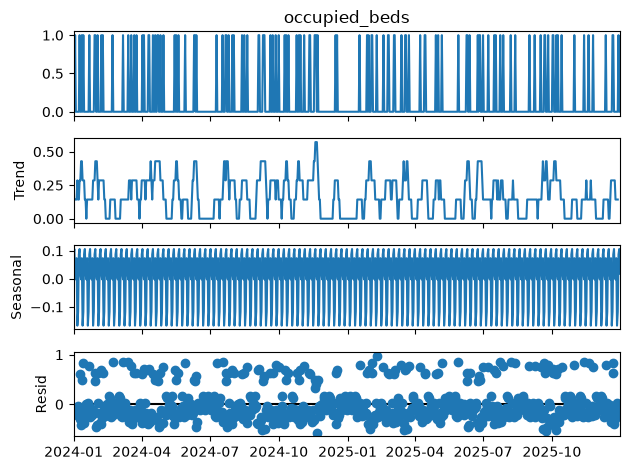

In [69]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    ts["occupied_beds"],
    model="additive",
    period=7
)

decomposition.plot()

plt.show()

In [70]:
ts["occupied_beds"]

date
2024-01-01    0
2024-01-02    0
2024-01-03    1
2024-01-04    0
2024-01-05    0
             ..
2025-12-27    0
2025-12-28    0
2025-12-29    1
2025-12-30    0
2025-12-31    0
Name: occupied_beds, Length: 731, dtype: int64

In [71]:
features = [
    "occupied_beds",
    "daily_admissions",
    "emergency_admissions",
    "daily_ed_arrivals",
    "scheduled_surgeries",
    "actual_staff",
    "staffing_ratio",
    "avg_los_hours"
]

corr = statistical_df[features].corr()

print(corr)

                      occupied_beds  daily_admissions  emergency_admissions  \
occupied_beds              1.000000          0.608217              0.547136   
daily_admissions           0.608217          1.000000              0.902706   
emergency_admissions       0.547136          0.902706              1.000000   
daily_ed_arrivals          0.399720          0.487270              0.479628   
scheduled_surgeries        0.187277          0.275300              0.069472   
actual_staff               0.626630          0.267215              0.201898   
staffing_ratio            -0.064296         -0.020940             -0.039562   
avg_los_hours              0.310635          0.127737              0.115673   

                      daily_ed_arrivals  scheduled_surgeries  actual_staff  \
occupied_beds                  0.399720             0.187277      0.626630   
daily_admissions               0.487270             0.275300      0.267215   
emergency_admissions           0.479628             0.

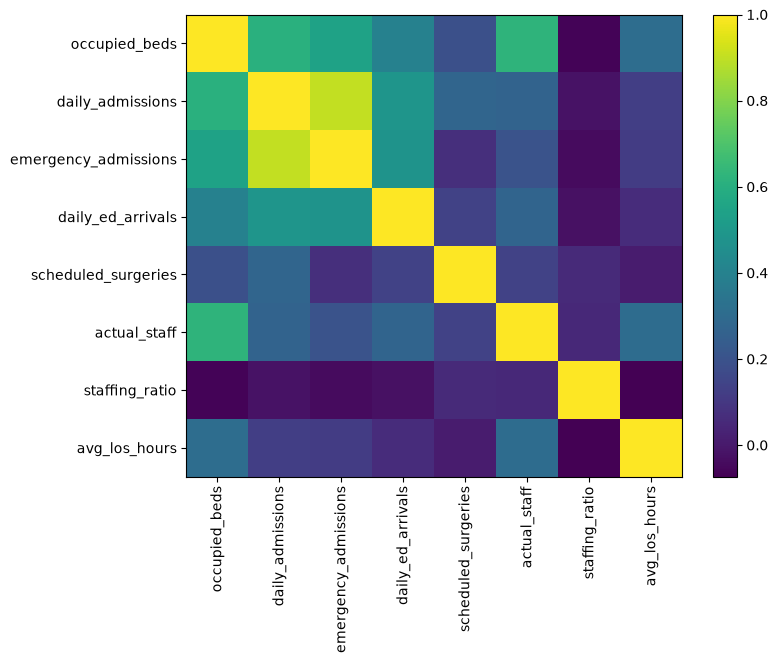

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.imshow(corr, aspect="auto")

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)

plt.yticks(range(len(corr.columns)), corr.columns)

plt.show()